# Used Car Price — first look at the data

Before writing the training script I wanted to actually look at what I was
working with. Dataset is the CarDekho used-car listings (name, year,
selling price, km driven, fuel, seller type, transmission, ownership
history) — about 4,340 rows scraped from the CarDekho site.

Goal for this notebook: understand what's messy about the data, check
which features actually seem to move the price, and decide on the cleaning
rules before I bake them into `src/data_processing.py`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

df = pd.read_csv("../data/cardekho_used_cars.csv")
df.shape

(4340, 8)

In [2]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


## Sanity checks

No nulls in this dataset (checked below), but there are duplicate rows and
some brand names are mangled straight out of the "name" column, so that's
where the real cleaning work is.

In [3]:
print(df.isnull().sum())
print("\nduplicate rows:", df.duplicated().sum())

name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64

duplicate rows: 763


In [4]:
df["brand"] = df["name"].str.split().str[0]
brand_counts = df["brand"].value_counts()
brand_counts.head(30)

brand
Maruti           1280
Hyundai           821
Mahindra          365
Tata              361
Honda             252
Ford              238
Toyota            206
Chevrolet         188
Renault           146
Volkswagen        107
Skoda              68
Nissan             64
Audi               60
BMW                39
Datsun             37
Fiat               37
Mercedes-Benz      35
Jaguar              6
Mitsubishi          6
Land                5
Volvo               4
Ambassador          4
Jeep                3
MG                  2
OpelCorsa           2
Daewoo              1
Force               1
Isuzu               1
Kia                 1
Name: count, dtype: int64

`Land` and `OpelCorsa` stick out immediately — "Land Rover" got split on
whitespace and lost its second word, and one listing has "Opel" and
"Corsa" stuck together with no space. Both get fixed explicitly in the
cleaning script rather than guessed at generically, since a generic rule
here would be more fragile than just hardcoding the two typos I can see.

In [5]:
df["year"].describe()

count    4340.000000
mean     2013.090783
std         4.215344
min      1992.000000
25%      2011.000000
50%      2014.000000
75%      2016.000000
max      2020.000000
Name: year, dtype: float64

Listings run from 1992 to 2020, so I'll treat 2020 as "now" for computing
car age instead of today's date — using the actual scrape date keeps the
age feature meaningful for cars that were already old when the data was
collected.

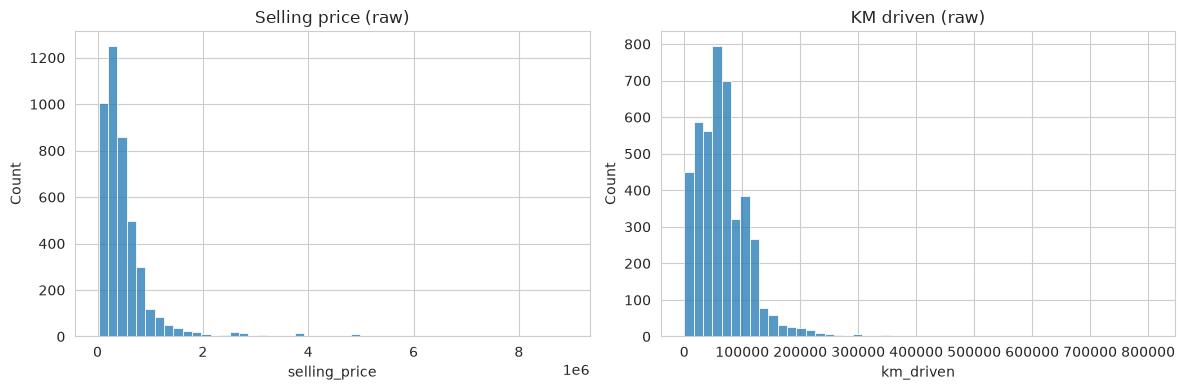

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["selling_price"], bins=50, ax=axes[0])
axes[0].set_title("Selling price (raw)")
sns.histplot(df["km_driven"], bins=50, ax=axes[1])
axes[1].set_title("KM driven (raw)")
plt.tight_layout()
plt.savefig("../reports/figures/raw_distributions.png", dpi=110)
plt.show()

Both are heavily right-skewed with a long tail of expensive/high-mileage
cars — a few multi-crore listings and a couple of cars past 500,000 km.
Rather than drop everything past some arbitrary cutoff, I used a widened
IQR rule (3x IQR instead of the usual 1.5x) in the cleaning script so
genuinely expensive cars (Audis, BMWs) don't all get treated as
outliers.

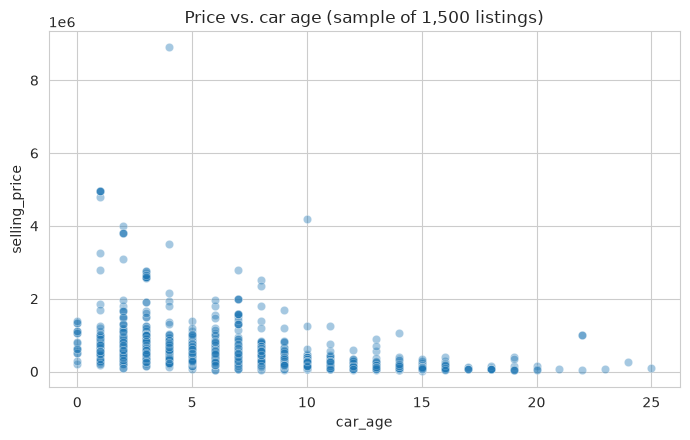

In [7]:
df["car_age"] = 2020 - df["year"]
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.scatterplot(data=df.sample(1500, random_state=42), x="car_age",
                 y="selling_price", alpha=0.4, ax=ax)
ax.set_title("Price vs. car age (sample of 1,500 listings)")
plt.tight_layout()
plt.savefig("../reports/figures/price_vs_age.png", dpi=110)
plt.show()

Pretty much the depreciation curve you'd expect — price drops off fast in
the first ~8 years and then flattens out. Confirms `car_age` is worth
including as a feature rather than raw `year`.

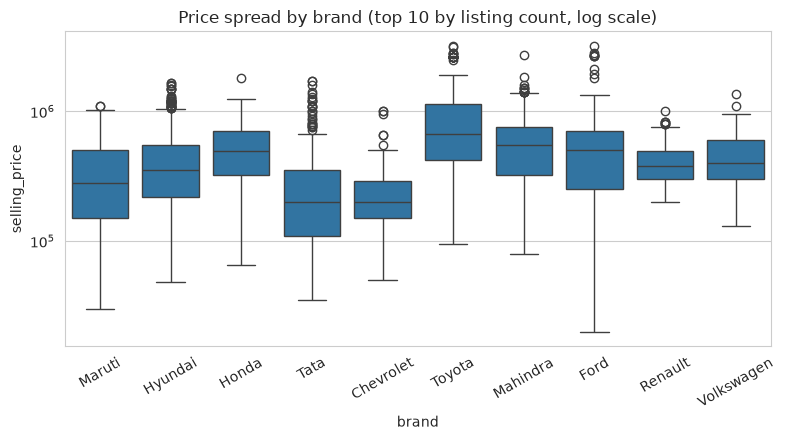

In [8]:
fig, ax = plt.subplots(figsize=(8, 4.5))
top_brands = df["brand"].value_counts().head(10).index
sns.boxplot(data=df[df["brand"].isin(top_brands)], x="brand",
            y="selling_price", ax=ax)
ax.set_yscale("log")
ax.set_title("Price spread by brand (top 10 by listing count, log scale)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("../reports/figures/price_by_brand.png", dpi=110)
plt.show()

Brand matters a lot — Maruti and Hyundai cluster low, Toyota and the
German brands (once you get past the "Other" bucket) sit much higher. That
was the deciding factor for one-hot encoding brand rather than dropping it
for being high-cardinality; it's clearly carrying price information the
other features don't.

In [9]:
df["owner"].value_counts()

owner
First Owner             2832
Second Owner            1106
Third Owner              304
Fourth & Above Owner      81
Test Drive Car            17
Name: count, dtype: int64

"Test Drive Car" is a small category (dealer demo units) and its price
behaviour doesn't follow normal depreciation — near-new mileage, prices
all over the place. I excluded that category in the cleaning step since
it's not representative of a normal resale and would just add noise.

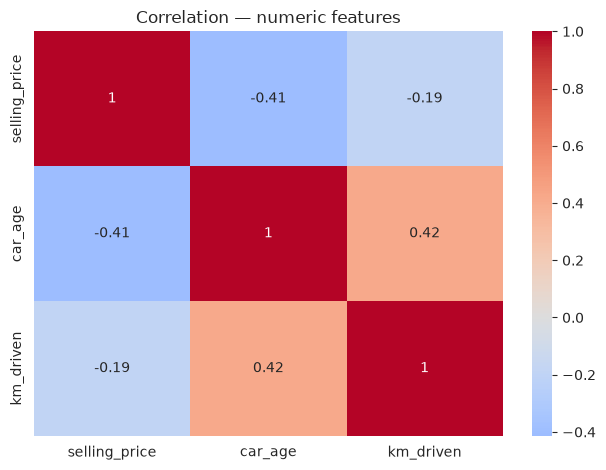

In [10]:
numeric_view = df.copy()
numeric_view["car_age"] = 2020 - numeric_view["year"]
corr = numeric_view[["selling_price", "car_age", "km_driven"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation — numeric features")
plt.tight_layout()
plt.savefig("../reports/figures/correlation.png", dpi=110)
plt.show()

Both `car_age` and `km_driven` correlate negatively with price, age more
strongly than mileage. Nothing here is a candidate to drop.

### Takeaways for `src/data_processing.py`

- Drop duplicate rows (763 of them).
- Fix the two mangled brand names, title-case the rest, bucket rare brands
  (fewer than 5 listings) into "Other".
- Convert `year` into `car_age` relative to 2020.
- Drop "Test Drive Car" listings.
- Trim outliers on price and km_driven using a widened (3x) IQR rule.

That logic is what actually ships in the cleaning module — this notebook
is just where I worked out why.